# LifePath — Project Log
# ======================
# Run this cell to print a full summary of your project so far

summary = """
===========================================
       LIFEPATH — DATA SCIENCE PROJECT
===========================================

WHAT IS IT?
  A CLI life simulation game where choices
  shift 4 stats over 14 rounds. Every run
  logs to CSV for data science analysis.

STATS
  Knowledge  start: 30
  Money      start: 20
  Health     start: 70
  Happiness  start: 60

CHOICES
  1. Study        +Knowledge, -Happiness, -Health
  2. Work harder  +Money, -Health, -Happiness
  3. Rest         +Health, +Happiness
  4. Risk         Weighted random outcome
  5. Social       +Happiness, -Money

HIDDEN MECHANICS
  Burnout    3x same hard choice = forced penalty
  Luck       Derived from happiness, shifts risk odds
  Momentum   2x same = small bonus, 4x = diminishing

ENDINGS (10 total)
  Balanced Developer    All stats >= 55
  Burnout Genius        Knowledge >= 85, Health <= 30
  The Grinder           Money >= 70, Happiness <= 35
  The Quiet Life        H + HP >= 150, Money <= 40
  Perpetual Student     Knowledge >= 80, Money <= 35
  Accidental Millionaire Money >= 85, 3+ risk wins
  Late Bloomer          Low stats early, 2+ late wins
  Social Butterfly      4+ social rounds, HP >= 60
  Crisis Recovery       2+ burnouts, final Health >= 60
  The Regret            Any stat <= 20 at end

SESSIONS PLAYED
  Run 1  Mixed strategy      → Balanced Developer
  Run 2  Pure work           → The Grinder
  Run 3  Pure risk           → Burnout Genius
  Run 4  Pure study          → Burnout Genius
  Run 5  Pure social         → The Quiet Life

DATASET
  Rows   : 70
  Runs   : 5
  Columns: player_id, round, age, choice,
           risk_outcome, knowledge, money,
           health, happiness, luck,
           social_count, ending

FINDINGS SO FAR
  - Knowledge is the #1 predictor at round 7
  - Knowledge >= 80 almost guarantees Burnout Genius
  - Money did not appear in the decision tree at all
  - Need 20-30 runs for real generalization

NEXT STEPS
  [ ] Play 5+ more mixed runs
  [ ] Fix burnout bug on pure work runs
  [ ] Feature importance bar chart
  [ ] Logistic regression model
  [ ] K-means player clustering
  [ ] Monte Carlo 10000 game simulation
===========================================
"""

print(summary)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/sessions.csv")

print(f"Rows: {len(df)}")
print(f"Runs: {df['player_id'].nunique()}")
print(df["ending"].value_counts())

Rows: 154
Runs: 11
ending
Balanced Developer    42
The Grinder           42
Burnout Genius        28
The Quiet Life        28
The Regret            14
Name: count, dtype: int64


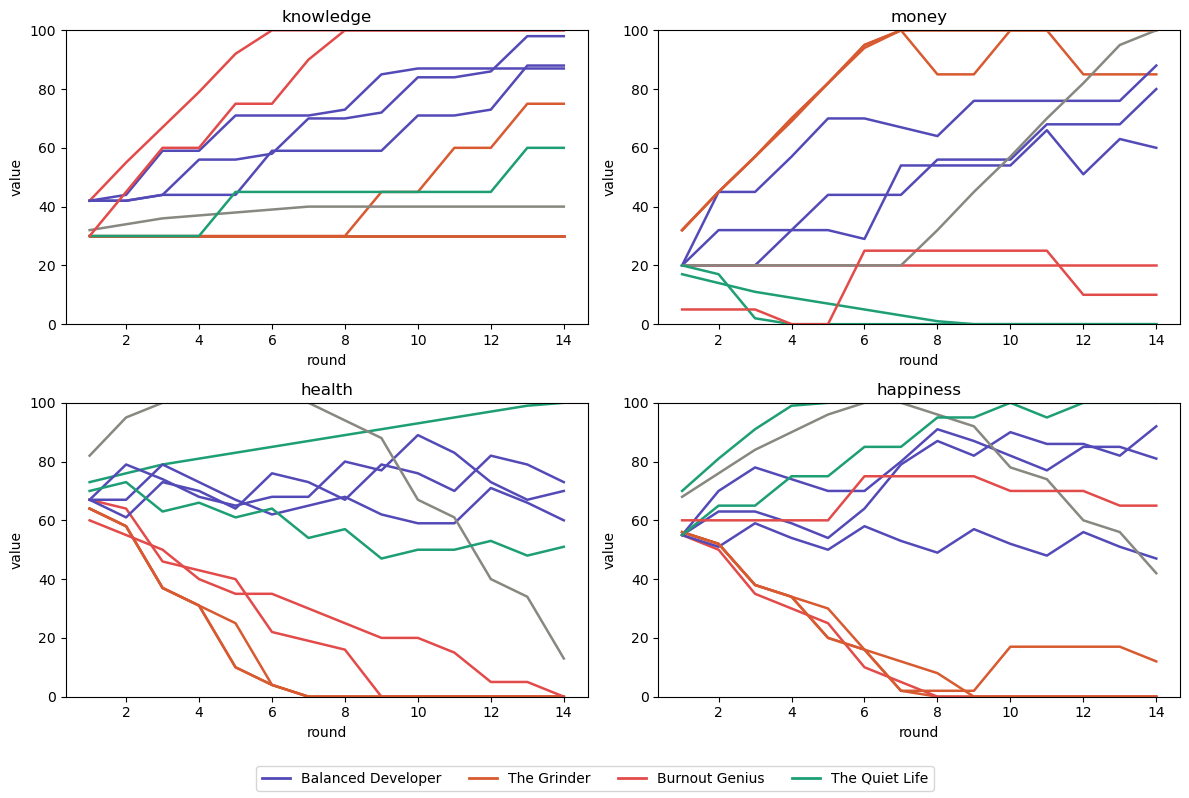

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
stats = ["knowledge", "money", "health", "happiness"]

ending_colors = {
    "Balanced Developer": "#534AB7",
    "The Grinder":        "#D85A30",
    "Burnout Genius":     "#E24B4A",
    "The Quiet Life":     "#1D9E75",
}

for ax, stat in zip(axes.flatten(), stats):
    for pid, group in df.groupby("player_id"):
        ending = group["ending"].iloc[0]
        color = ending_colors.get(ending, "#888780")
        ax.plot(group["round"], group[stat], color=color, linewidth=1.8)
    ax.set_title(stat)
    ax.set_ylim(0, 100)
    ax.set_xlabel("round")
    ax.set_ylabel("value")

handles = [plt.Line2D([0],[0], color=c, linewidth=2, label=l) for l,c in ending_colors.items()]
fig.legend(handles=handles, loc="lower center", ncol=4)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

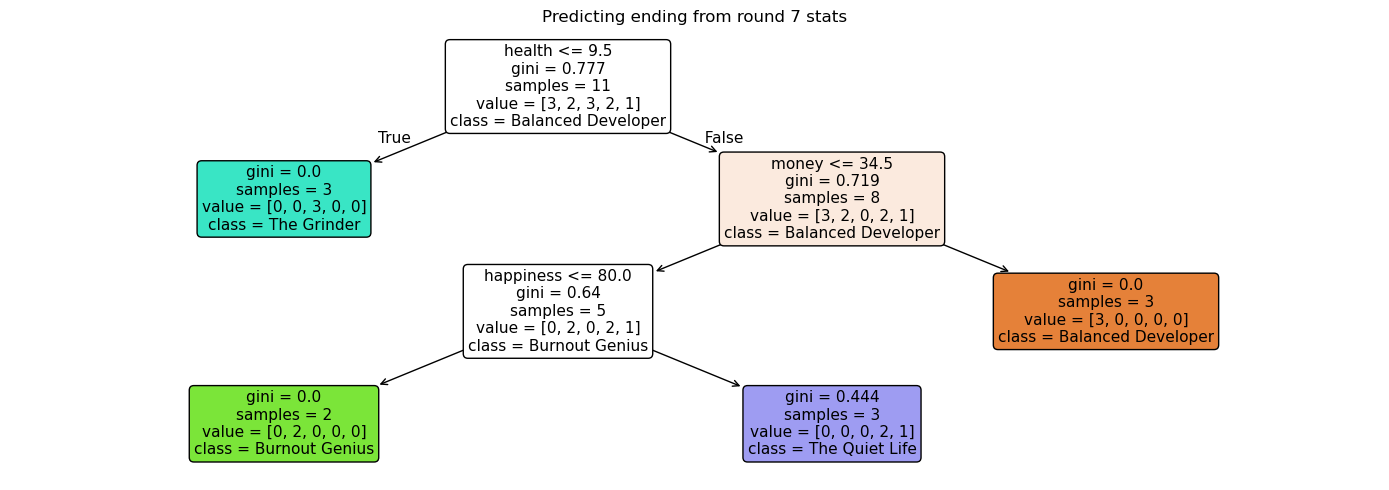

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

mid = df[df["round"] == 7][["knowledge","money","health","happiness","ending"]]
X = mid[["knowledge","money","health","happiness"]]
y = mid["ending"]

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(model, feature_names=X.columns, class_names=model.classes_,
          filled=True, rounded=True, ax=ax)
plt.title("Predicting ending from round 7 stats")
plt.tight_layout()
plt.show()

In [4]:
# reload fresh data
df = pd.read_csv("../data/sessions.csv")

print(f"Rows: {len(df)}")
print(f"Runs: {df['player_id'].nunique()}")
print()
print(df.groupby("player_id").last()[["ending"]])

Rows: 154
Runs: 11

                       ending
player_id                    
01dd562e       The Quiet Life
35f75488          The Grinder
67309d17   Balanced Developer
87ffaaa4       Burnout Genius
90f40368   Balanced Developer
9be8a4c7          The Grinder
9d854fbb   Balanced Developer
acf32168          The Grinder
af992511           The Regret
e6e3c0c0       The Quiet Life
f7f26f86       Burnout Genius


Training samples: 11
Endings in tree: ['Balanced Developer', 'Burnout Genius', 'The Grinder', 'The Quiet Life', 'The Regret']


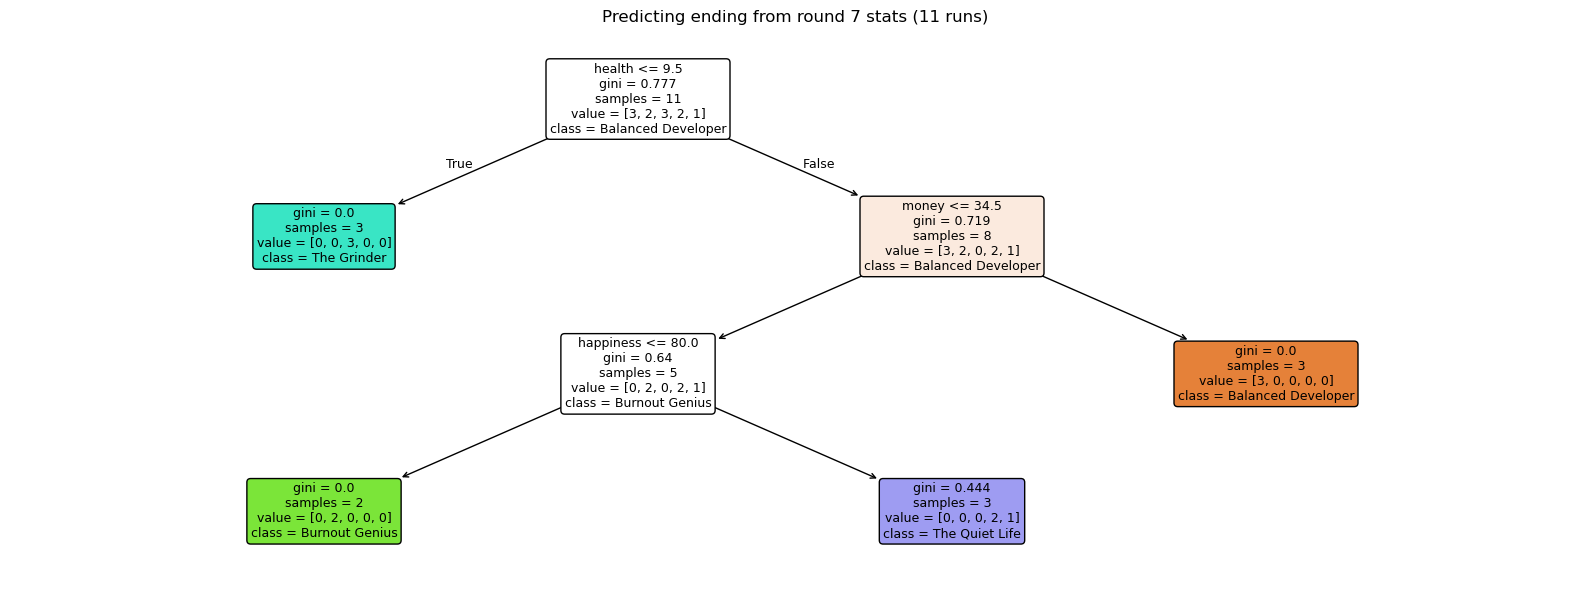

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

mid = df[df["round"] == 7][["knowledge","money","health","happiness","ending"]]
X = mid[["knowledge","money","health","happiness"]]
y = mid["ending"]

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

print(f"Training samples: {len(X)}")
print(f"Endings in tree: {list(model.classes_)}")

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(model, feature_names=X.columns, class_names=model.classes_,
          filled=True, rounded=True, ax=ax, fontsize=9)
plt.title("Predicting ending from round 7 stats (11 runs)")
plt.tight_layout()
plt.show()

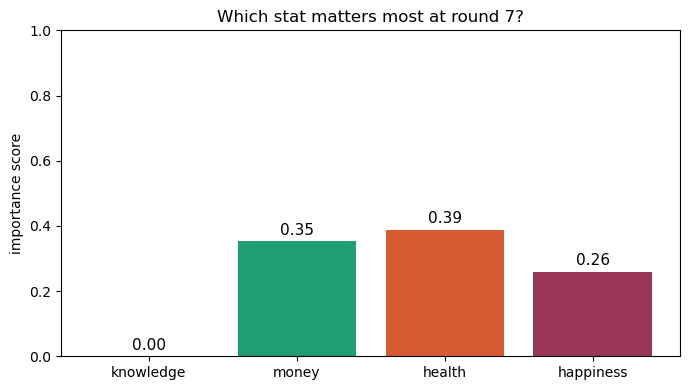

In [6]:
features = ["knowledge", "money", "health", "happiness"]
importances = model.feature_importances_

plt.figure(figsize=(7, 4))
bars = plt.bar(features, importances,
               color=["#534AB7","#1D9E75","#D85A30","#993556"])
plt.title("Which stat matters most at round 7?")
plt.ylabel("importance score")
plt.ylim(0, 1)

for bar, val in zip(bars, importances):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f"{val:.2f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
import matplotlib.pyplot as plt

df = pd.read_csv('../data/sessions.csv')
print(df.shape)
df.head()

(154, 12)


,player_id,round,age,choice,risk_outcome,knowledge,money,health,happiness,luck,social_count,ending
0,67309d17,1,18,Study / Learn,NaN,42,20,67,55,11,0,Balanced Developer
1,67309d17,2,19,Rest / Invest in self,NaN,44,20,79,63,12,0,Balanced Developer
2,67309d17,3,20,Take a risk,Learned a lesson.,59,20,74,63,12,0,Balanced Developer
3,67309d17,4,21,Work harder,NaN,59,32,68,59,11,0,Balanced Developer
4,67309d17,5,22,Study / Learn,NaN,71,32,65,54,10,0,Balanced Developer


In [8]:
# One row per player, using their Round 7 snapshot
r7 = df[df['round'] == 7].copy().drop(columns=['ending'])

# Grab the final ending for each player
endings = df.groupby('player_id')['ending'].last().reset_index()

# Join them together
data = r7.merge(endings, on='player_id')

print(data.shape)
print(data[['player_id', 'health', 'money', 'happiness', 'knowledge', 'ending']].to_string())

(11, 12)
   player_id  health  money  happiness  knowledge              ending
0   67309d17      68     54         79         71  Balanced Developer
1   acf32168       0    100         12         30         The Grinder
2   f7f26f86      30     25         75         90      Burnout Genius
3   87ffaaa4      19     20          5        100      Burnout Genius
4   01dd562e      87      3        100         30      The Quiet Life
5   35f75488       0    100          2         30         The Grinder
6   9be8a4c7       0    100          2         30         The Grinder
7   af992511     100     20        100         40          The Regret
8   e6e3c0c0      54      0         85         45      The Quiet Life
9   90f40368      73     44         53         70  Balanced Developer
10  9d854fbb      65     67         80         59  Balanced Developer


In [9]:
FEATURES = ['knowledge', 'money', 'health', 'happiness', 'luck', 'social_count']

X = data[FEATURES].values
y = data['ending'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Let's see what scaling actually did
before_after = pd.DataFrame({
    'feature': FEATURES,
    'mean_before': X.mean(axis=0).round(1),
    'mean_after':  X_scaled.mean(axis=0).round(2),
    'std_before':  X.std(axis=0).round(1),
    'std_after':   X_scaled.std(axis=0).round(2),
})
print(before_after.to_string(index=False))

     feature  mean_before  mean_after  std_before  std_after
   knowledge         54.1        -0.0        24.4        1.0
       money         48.5         0.0        36.9        1.0
      health         45.1        -0.0        35.1        1.0
   happiness         53.9         0.0        38.7        1.0
        luck         10.9         0.0         7.4        1.0
social_count          1.1         0.0         2.1        1.0


In [10]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_scaled, y)

loo = LeaveOneOut()
scores = cross_val_score(lr, X_scaled, y, cv=loo)

print(f"LOO-CV Accuracy: {scores.mean():.2f}")
print(f"Correct predictions: {scores.sum():.0f} / {len(scores)}")

LOO-CV Accuracy: 0.82
Correct predictions: 9 / 11


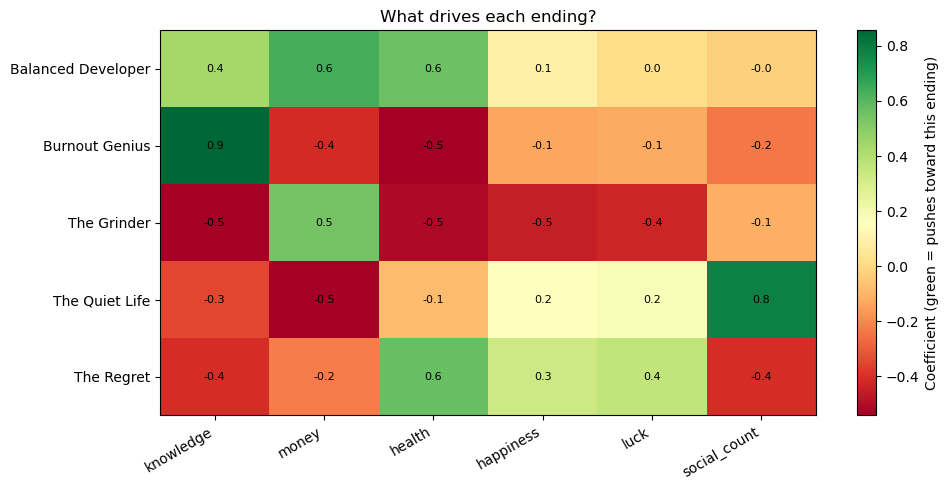

In [11]:
coef_df = pd.DataFrame(
    lr.coef_,
    index=lr.classes_,
    columns=FEATURES
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(coef_df.values, aspect='auto', cmap='RdYlGn')

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=30, ha='right')
ax.set_yticks(range(len(lr.classes_)))
ax.set_yticklabels(lr.classes_)

# Write the actual numbers inside each cell
for i in range(len(lr.classes_)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f'{coef_df.iloc[i,j]:.1f}', ha='center', va='center', fontsize=8)

plt.colorbar(im, label='Coefficient (green = pushes toward this ending)')
ax.set_title('What drives each ending?')
plt.tight_layout()
plt.show()

   player_id              ending  cluster
2   67309d17  Balanced Developer        0
4   90f40368  Balanced Developer        0
6   9d854fbb  Balanced Developer        0
1   35f75488         The Grinder        1
5   9be8a4c7         The Grinder        1
7   acf32168         The Grinder        1
8   af992511          The Regret        1
0   01dd562e      The Quiet Life        2
9   e6e3c0c0      The Quiet Life        2
3   87ffaaa4      Burnout Genius        3
10  f7f26f86      Burnout Genius        3


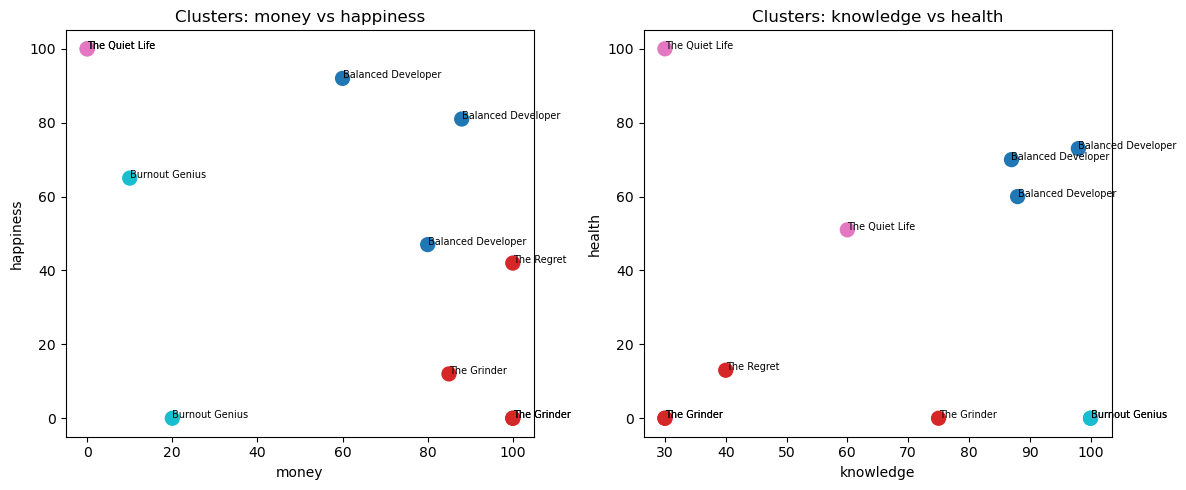

In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# use final round stats per player
final = df.groupby("player_id").last().reset_index()
X_cluster = final[["knowledge","money","health","happiness"]]

# scale before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# fit kmeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final["cluster"] = kmeans.fit_predict(X_scaled)

# show who landed where
print(final[["player_id","ending","cluster"]].sort_values("cluster"))

# visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(final["money"], final["happiness"],
                c=final["cluster"], cmap="tab10", s=100)
for _, row in final.iterrows():
    axes[0].annotate(row["ending"], (row["money"], row["happiness"]),
                     fontsize=7, ha="left")
axes[0].set_xlabel("money")
axes[0].set_ylabel("happiness")
axes[0].set_title("Clusters: money vs happiness")

axes[1].scatter(final["knowledge"], final["health"],
                c=final["cluster"], cmap="tab10", s=100)
for _, row in final.iterrows():
    axes[1].annotate(row["ending"], (row["knowledge"], row["health"]),
                     fontsize=7, ha="left")
axes[1].set_xlabel("knowledge")
axes[1].set_ylabel("health")
axes[1].set_title("Clusters: knowledge vs health")

plt.tight_layout()
plt.show()